# The Fourth Circle: Neural Networks, Part Two 
## Convolutional Neural Networks VII

<br/>
Jiří Fejlek

2026-03-25
<br/>

We will continue our series about modern convolutional neural networks with DenseNet [[1](#1)] from 2017. DenseNet is a bit of a continuation of the ResNet architecture, which we discussed in the previous project [[2](#2)]. We learned that ResNet introduced residual connections, which allowed the input to skip convolutional layers. The results of these layers and the original input were then added to produce the final output of the given residual block. In DenseNet, these various outputs are concatenated instead. Hence, the DenseNet architecture keeps all these provisional outputs from the convolutional blocks as the data passes through the network.

## Table of Contents

- [DenseNet](#densenet)
    - [Dense Block](#denseblock)
    - [DenseNet Architectures](#DenseNets)
    - [Training DenseNets on Fashion-MNIST and CIFAR-10](#training)
- [References](#references)

## DenseNet <a class="anchor" id="densenet"></a>

To start out, we repeat the common parts of our implementation from our previous projects.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [3]:
def layer_summary(nn_model, X_shape):
    X = torch.randn(*X_shape)
    for layer in nn_model.net_stack:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

In [4]:
def init_weights_he(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0) 
    if isinstance(model, nn.Conv2d):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0)  

In [5]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

### Dense Block <a class="anchor" id="denseblock"></a>

As we mentioned in the introduction, the DenseNet CNN consists of *dense blocks* that are similar to residual blocks [[1](#1)].

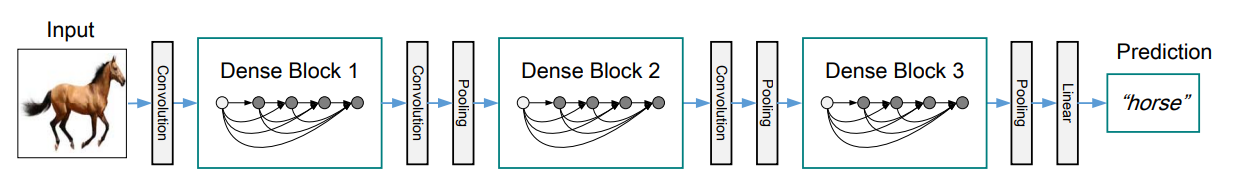

However, the addition at the end of the residual block is replaced with concatenation [[3](#3)].

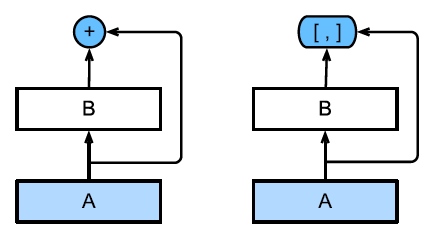

DenseNet blocks also use an alternative order of operations. Up to this point, all the CNNs we introduced have used the "standard" ordering: convolution layer, batch normalization, and a nonlinear activation. Some later CNNs, such as DenseNet [[1](#1)], experimented with an alternative order of operations, namely, batch normalization, nonlinear activation, and convolution.

In [6]:
def conv_block(num_channels):
    return nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(), nn.LazyConv2d(4*num_channels, kernel_size=1),
        nn.LazyBatchNorm2d(), nn.ReLU(), nn.LazyConv2d(num_channels, kernel_size=3, padding=1))

In [7]:
class DenseNet_block(nn.Module):

    def __init__(self, num_convs, num_channels):
        super().__init__()
        
        convolution_stack = []
        for i in range(num_convs):
            convolution_stack.append(conv_block(num_channels))

        self.net_stack = nn.Sequential(*convolution_stack) 

    def forward(self, x):
   
        for blk in self.net_stack:
            y = blk(x)
            x = torch.cat((x, y), dim=1) # Concatenate input and output of each block along the channels
        return x

One important observation to keep in mind is the fact that since DenseNet blocks repeatedly concatenate the outputs of dense blocks, the number of channels of the output progressively increases (each block adds *num_convs* x *num_channels* channels to the original input). hence, to control the number of channels, DenseNet [[1](#1)] also uses so-called *transition layers*, that reduces the number of channels by a given factor (we will reduce the number of channels by one half, which is also the version that was used in [[1](#1)]). These transition layers also perform downsampling. 

In [8]:
def transition_layer(num_channels):
    return nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(), nn.LazyConv2d(num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2)
    )

### DenseNet Architectures <a class="anchor" id="DenseNets"></a>

Overall, we have the following DenseNet architectures designed for the ImageNet dataset.

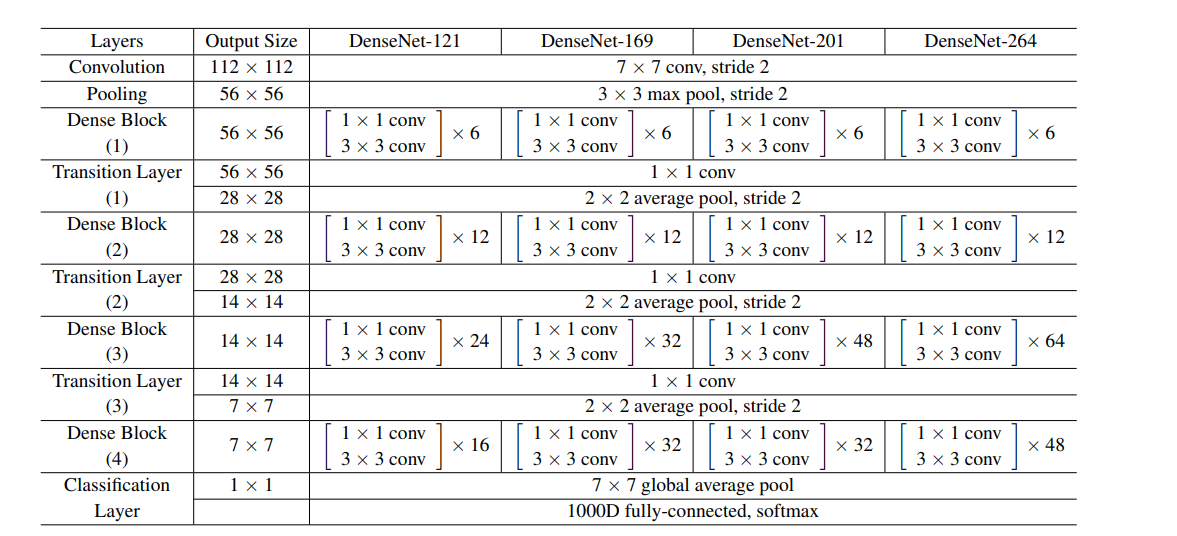

The main parameter of the DenseNet architecture is the growth rate, which is the number of channels added to the output after each residual/skip connection. The architectures in [[1](#1)] use a growth rate of $k = 32$, i.e., each layer adds 32 additional channels.


### Training DenseNets on Fashion-MNIST and CIFAR-10 <a class="anchor" id="training"></a>

Let us implement DenseNet-121 from the table [[1](#1)].

In [9]:
class DenseNet_121(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),  nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        # dense blocks
        self.b2 =  nn.Sequential(
            DenseNet_block(6, 32),
            transition_layer(128), # (6*32 + 64)/2
            DenseNet_block(12, 32),
            transition_layer(256), # (12*32 + 128)/2
            DenseNet_block(24, 32),
            transition_layer(512), # (24*32 + 256)/2
            DenseNet_block(16, 32)
        )

        self.net_stack = nn.Sequential(
            self.b1, self.b2,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [10]:
layer_summary(DenseNet_121(10),(1, 1, 64, 64))

Sequential output shape:	 torch.Size([1, 64, 16, 16])
Sequential output shape:	 torch.Size([1, 1024, 2, 2])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 1024, 1, 1])
Flatten output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


As usual, we will train the DenseNet model on the Fashion-MNIST dataset [[4](#4)].

In [11]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# DenseNet initialization
DenseNet_121_cuda = DenseNet_121(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
DenseNet_121_cuda(x);
DenseNet_121_cuda.apply(init_weights_he);

The parameter count of DenseNet-121 is as follows.

In [12]:
sum(p.numel() for p in DenseNet_121_cuda.parameters() if p.requires_grad)

6966026

In [13]:
optim_SGD_cuda =  torch.optim.Adam(DenseNet_121_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, DenseNet_121_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2433.117913246155


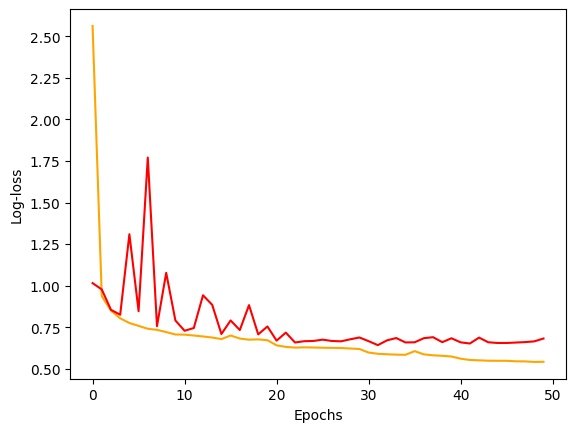

In [14]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

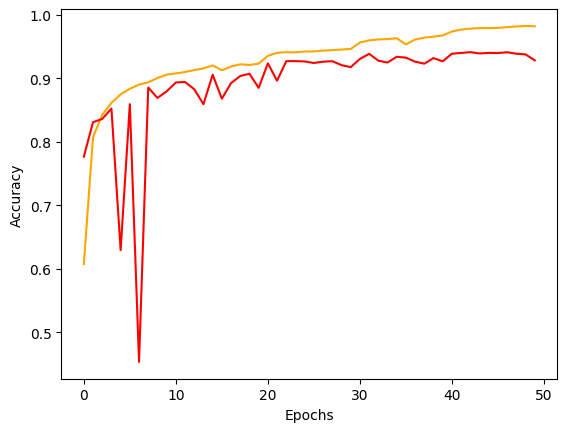

In [15]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

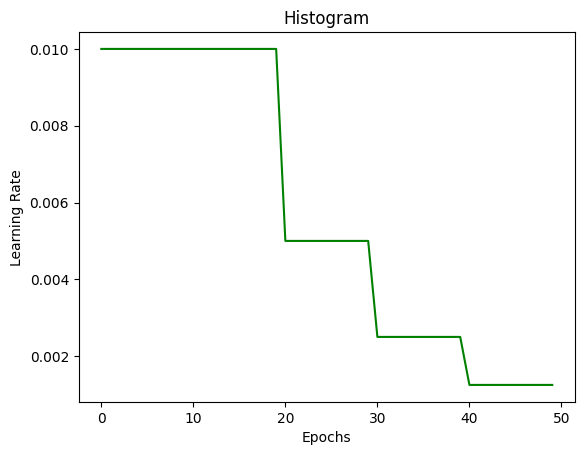

In [16]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [17]:
accu_epochs_train[49]

0.9819499850273132

In [18]:
accu_epochs_test[49]

0.9282999634742737

In [19]:
accu_epochs_test.max()

0.9412999749183655

We obtained a pretty good performance. Let us try DenseNet-201 [[1](#1)] next.

In [20]:
class DenseNet_201(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),  nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        # dense blocks
        self.b2 =  nn.Sequential(
            DenseNet_block(6, 32),
            transition_layer(128), # (6*32 + 64)/2
            DenseNet_block(12, 32),
            transition_layer(256), # (12*32 + 128)/2
            DenseNet_block(48, 32),
            transition_layer(896), # (48*32 + 256)/2
            DenseNet_block(32, 32)
        )

        self.net_stack = nn.Sequential(
            self.b1, self.b2,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [21]:
layer_summary(DenseNet_201(10),(1, 1, 64, 64))

Sequential output shape:	 torch.Size([1, 64, 16, 16])
Sequential output shape:	 torch.Size([1, 1920, 2, 2])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 1920, 1, 1])
Flatten output shape:	 torch.Size([1, 1920])
Linear output shape:	 torch.Size([1, 10])


In [22]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# DenseNet initialization
DenseNet_201_cuda = DenseNet_201(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
DenseNet_201_cuda(x);
DenseNet_201_cuda.apply(init_weights_he);

DenseNet-201 has many more parameters than DenseNet-121. 

In [23]:
sum(p.numel() for p in DenseNet_201_cuda.parameters() if p.requires_grad)

18119050

In [24]:
optim_SGD_cuda =  torch.optim.Adam(DenseNet_201_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[20, 30, 40], gamma = 0.5)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, DenseNet_201_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2976.943069458008


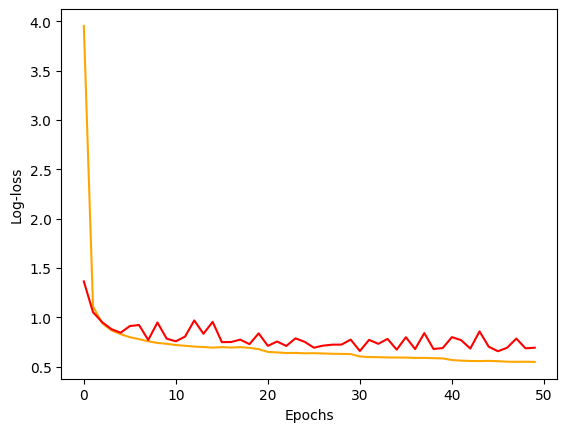

In [25]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

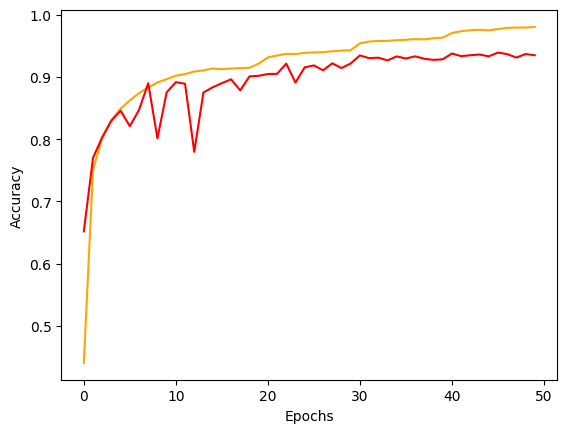

In [26]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

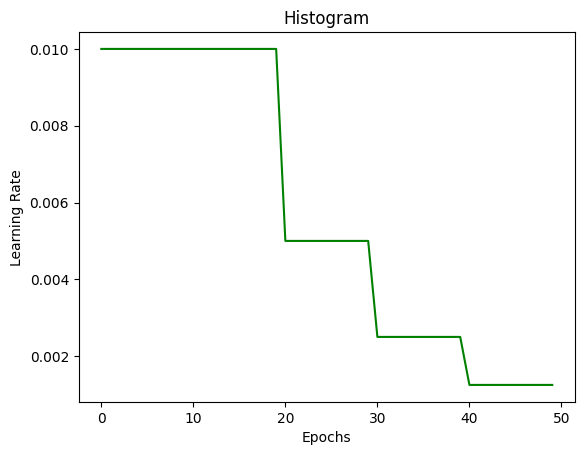

In [27]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [28]:
accu_epochs_train[49]

0.9801000356674194

In [29]:
accu_epochs_test[49]

0.9346999526023865

In [30]:
accu_epochs_test.max()

0.9388999938964844

The performance is slightly worse; we would probably need to tweak the training hyperparameters a bit to match that of DenseNet-121. We need to note again that both networks were designed for the much larger ImageNet dataset (both in image resolution and the number of images). Hence, let us try our own version of DenseNet, more suitable for the Fashion-MNIST dataset.

In [31]:
class DenseNet_52(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(48, kernel_size=3, stride=1, padding=1),  nn.LazyBatchNorm2d(), nn.ReLU()
        )
        
        # dense blocks
        self.b2 =  nn.Sequential(
            DenseNet_block(8, 24),
            transition_layer(120), # (8*24 + 48)/2
            DenseNet_block(8, 24),
            transition_layer(156), # (8*24 + 60)/2
            DenseNet_block(8, 24)
        )

        self.net_stack = nn.Sequential(
            self.b1, self.b2,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [32]:
layer_summary(DenseNet_52(10),(1, 1, 28, 28))

Sequential output shape:	 torch.Size([1, 48, 28, 28])
Sequential output shape:	 torch.Size([1, 348, 7, 7])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 348, 1, 1])
Flatten output shape:	 torch.Size([1, 348])
Linear output shape:	 torch.Size([1, 10])


In [33]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [28, 28], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# resnet initialization
DenseNet_52_cuda = DenseNet_52(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
DenseNet_52_cuda(x);
DenseNet_52_cuda.apply(init_weights_he);

In [34]:
sum(p.numel() for p in DenseNet_52_cuda.parameters() if p.requires_grad)

1039654

In [35]:
optim_SGD_cuda =  torch.optim.Adam(DenseNet_52_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[50], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, DenseNet_52_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

3445.9523615837097


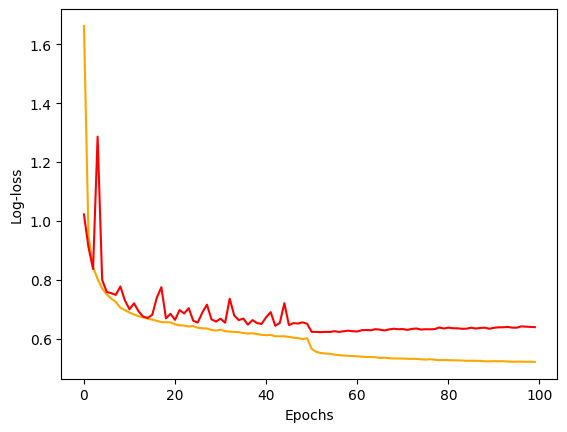

In [36]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

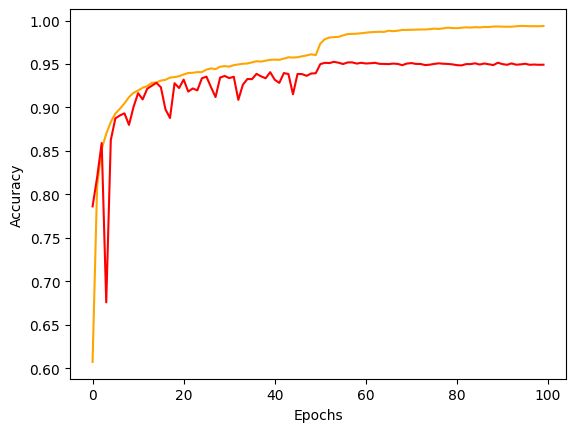

In [37]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

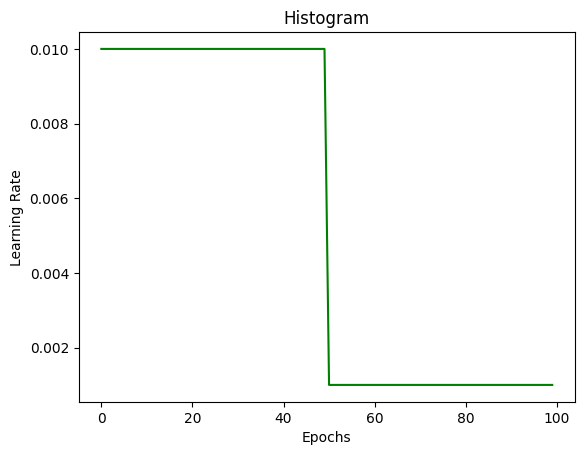

In [38]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [39]:
accu_epochs_train[99]

0.9937500357627869

In [40]:
accu_epochs_test[99]

0.9491999745368958

In [41]:
accu_epochs_test.max()

0.9524999856948853

This is our best model so far on this dataset. We improved the accuracy on the test set from about 94,5% from the last project (ResNet and ResNeXt) to 95%.

The DenseNet models can become quite large; hence, let us delete them before we create our model for the CIFAR-10 dataset.

In [42]:
del DenseNet_121_cuda
del DenseNet_201_cuda
del DenseNet_52_cuda
torch.cuda.empty_cache()

We will use the following architecture, inspired by DenseNets, for the CIFAR-10 dataset from [[1](#1)].

In [43]:
class DenseNet_100(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(48, kernel_size=3, stride=1, padding=1),  nn.LazyBatchNorm2d(), nn.ReLU()
        )
        
        # dense blocks
        self.b2 =  nn.Sequential(
            DenseNet_block(16, 24),
            transition_layer(216), # (16*24 + 48)/2
            DenseNet_block(16, 24),
            transition_layer(300), # (16*24 + 216)/2
            DenseNet_block(16, 24)
        )

        self.net_stack = nn.Sequential(
            self.b1, self.b2,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [44]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 125, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 125, shuffle = False)

# DenseNet initialization
DenseNet_100_cuda = DenseNet_100(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
DenseNet_100_cuda(x);
DenseNet_100_cuda.apply(init_weights_he);

In [45]:
sum(p.numel() for p in DenseNet_100_cuda.parameters() if p.requires_grad)

3025558

In [46]:
optim_SGD_cuda = torch.optim.Adam(DenseNet_100_cuda.parameters(), lr = 0.01, betas=(0.9, 0.999), weight_decay = 0)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[75, 125], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, DenseNet_100_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

14326.399995326996


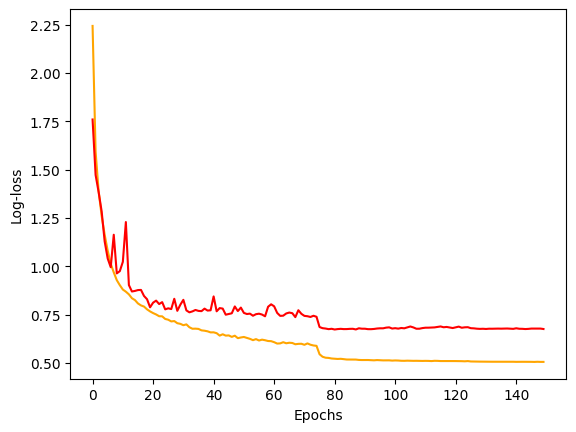

In [47]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

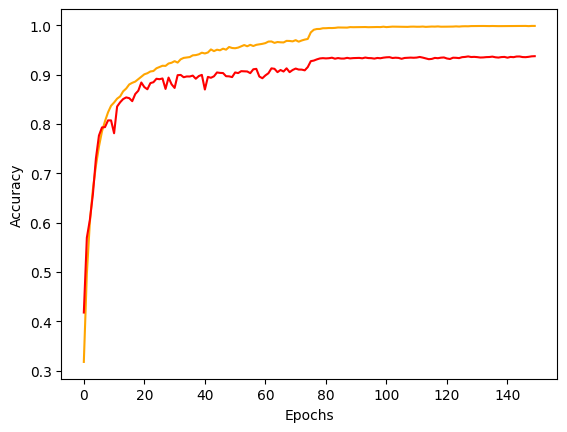

In [48]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

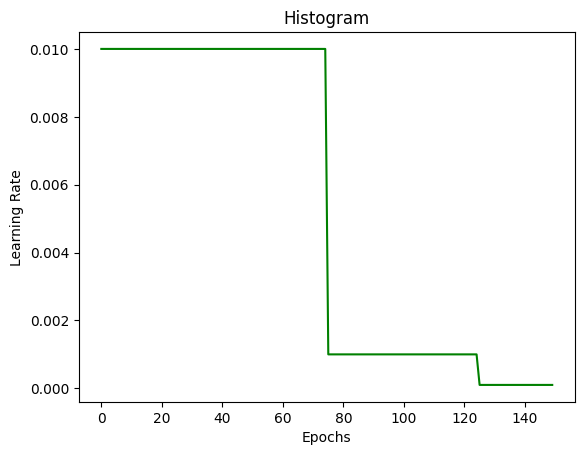

In [49]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [50]:
accu_epochs_train[149]

0.9990599751472473

In [51]:
accu_epochs_test[149]

0.9376999735832214

In [52]:
accu_epochs_test.max()

0.9376999735832214

The test set accuracy is close to 94%, which is quite decent. We should note that the DenseNet architecture can achieve the test set accuracy over 96% according to [[1](#1)]. However, training DenseNet on CIFAR-10 using a single GPU can be quite tedious (our smaller model with 3 million parameters already took over 3 hours to train; the model that attained best accuracy had *over* 26 million parameters).

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> HUANG, Gao, et al. Densely connected convolutional networks. In: *Proceedings of the IEEE conference on computer vision and pattern recognition.* 2017. p. 4700-4708.

<a id="2">[2]</a> HE, Kaiming, et al. Deep residual learning for image recognition. In: *Proceedings of the IEEE conference on computer vision and pattern recognition.* 2016. p. 770-778.

<a id="3">[3]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.

<a id="4">[4]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-mnist: a novel image dataset for benchmarking machine learning algorithms. arXiv preprint arXiv:1708.07747, 2017.